In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data_train = pd.read_csv("/content/Google_Stock_Price_Train.csv")
data_train.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [ ]:
data_train.info()

In [ ]:
train_set = data_train[['Open']].values
train_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
train_set = scaler.fit_transform(train_set)
train_set

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

In [ ]:
### Divide the data into time steps
#data = 10,20,30,40,50,60,70,80,90,100
#time_step = 2
#xtrain = [10,20],[20,30],[30,40],[40,50],[50,60]......
#ytrain = 30,40,50,60,70....

In [ ]:
xtrain = []
ytrain = []
## time step = 60 days
for i in range(60,len(data_train)):
  xtrain.append(train_set[i-60:i,0])
  ytrain.append(train_set[i,0])
xtrain,ytrain = np.array(xtrain),np.array(ytrain)

In [ ]:
xtrain

array([[0.08581368, 0.09701243, 0.09433366, ..., 0.07846566, 0.08034452,
        0.08497656],
       [0.09701243, 0.09433366, 0.09156187, ..., 0.08034452, 0.08497656,
        0.08627874],
       [0.09433366, 0.09156187, 0.07984225, ..., 0.08497656, 0.08627874,
        0.08471612],
       ...,
       [0.92106928, 0.92438053, 0.93048218, ..., 0.95475854, 0.95204256,
        0.95163331],
       [0.92438053, 0.93048218, 0.9299055 , ..., 0.95204256, 0.95163331,
        0.95725128],
       [0.93048218, 0.9299055 , 0.93113327, ..., 0.95163331, 0.95725128,
        0.93796041]])

In [ ]:
ytrain

array([0.08627874, 0.08471612, 0.07454052, ..., 0.95725128, 0.93796041,
       0.93688146])

In [ ]:
xtrain.shape

(1198, 60)

In [ ]:
xtrain = xtrain.reshape(xtrain.shape[0],xtrain.shape[1],1)
xtrain.shape

(1198, 60, 1)

In [ ]:
### RNN

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Dropout

In [ ]:
model = Sequential()
model.add(SimpleRNN(units=50,input_shape=(xtrain.shape[1],1)))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(optimizer='adam',loss='mean_squared_error')

In [ ]:
### Train the model
model.fit(xtrain,ytrain,epochs=100)

Epoch 1/100
38/38 [==============================] - 2s 11ms/step - loss: 0.0643
Epoch 2/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0136
Epoch 3/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0099
Epoch 4/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0082
Epoch 5/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0065
Epoch 6/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0051
Epoch 7/100
38/38 [==============================] - 0s 11ms/step - loss: 0.0048
Epoch 8/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0047
Epoch 9/100
38/38 [==============================] - 0s 11ms/step - loss: 0.0042
Epoch 10/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0044
Epoch 11/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0033
Epoch 12/100
38/38 [==============================] - 0s 10ms/step - loss: 0.0037
Epoch 13/100
38/38 [=====

In [ ]:
data_test = pd.read_csv("/content/Google_Stock_Price_Test.csv")
real_stock_price = data_test[['Open']].values
real_stock_price

In [ ]:
dataset_total = pd.concat((data_train['Open'],data_test['Open']),axis=0)
dataset_total

0     325.25
1     331.27
2     329.83
3     328.34
4     322.04
       ...  
15    829.62
16    837.81
17    834.71
18    814.66
19    796.86
Name: Open, Length: 1278, dtype: float64

In [ ]:
inputs = dataset_total[len(dataset_total)-len(data_test)-60:].values
inputs = inputs.reshape(-1,1)
inputs = scaler.transform(inputs)
inputs

In [ ]:
x_test = []
for i in range(60,len(inputs)):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0],x_test.shape[1])

In [ ]:
x_test

array([[0.9299055 , 0.93113327, 0.92750577, ..., 0.95725128, 0.93796041,
        0.93688146],
       [0.93113327, 0.92750577, 0.94415507, ..., 0.93796041, 0.93688146,
        0.92955205],
       [0.92750577, 0.94415507, 0.93876032, ..., 0.93688146, 0.92955205,
        0.94731751],
       ...,
       [0.96054394, 0.9371419 , 0.92841729, ..., 1.01045465, 1.02407173,
        1.03930724],
       [0.9371419 , 0.92841729, 0.90804747, ..., 1.02407173, 1.03930724,
        1.03354044],
       [0.92841729, 0.90804747, 0.8771858 , ..., 1.03930724, 1.03354044,
        0.99624228]])

In [ ]:
predicted_stock_price = model.predict(x_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)
predicted_stock_price

1/1 [==============================] - 0s 239ms/step


array([[788.3163 ],
       [783.18866],
       [789.52783],
       [793.6265 ],
       [800.5037 ],
       [810.6447 ],
       [814.23126],
       [811.39014],
       [810.47375],
       [811.97485],
       [812.4352 ],
       [812.58154],
       [809.6072 ],
       [810.0992 ],
       [812.2351 ],
       [822.8797 ],
       [831.0351 ],
       [841.60077],
       [839.74805],
       [825.1705 ]], dtype=float32)

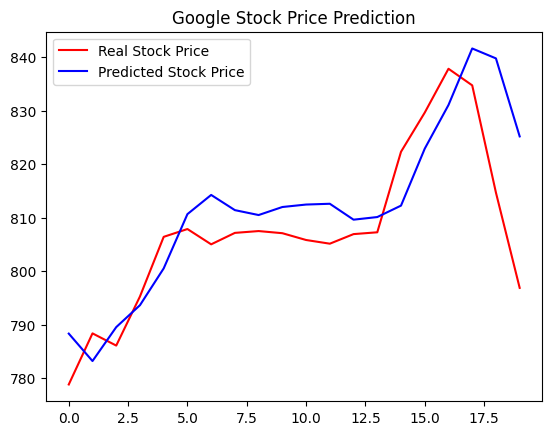

In [ ]:
### Vislualize the result
plt.plot(real_stock_price,color="red",label="Real Stock Price")
plt.plot(predicted_stock_price,color="blue",label="Predicted Stock Price")
plt.title("Google Stock Price Prediction")
plt.legend()
plt.show()